<a href="https://colab.research.google.com/github/tasosquantumcomputing/Machine-Learning/blob/main/SupportVectorRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries
---



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Dataset

In [2]:
df = pd.read_csv("auto-mpg.csv")

Exploratory data analysis

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
print(df.isnull().sum())


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [7]:
print((df == '?').sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [8]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = df['horsepower'].astype(float)
df = df.dropna()

Features

In [9]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

Statistical Analysis

In [11]:
corr = df.corr(numeric_only=True)
print(corr['mpg'].sort_values(ascending=False))

mpg             1.000000
model year      0.580541
origin          0.565209
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


Visualisation

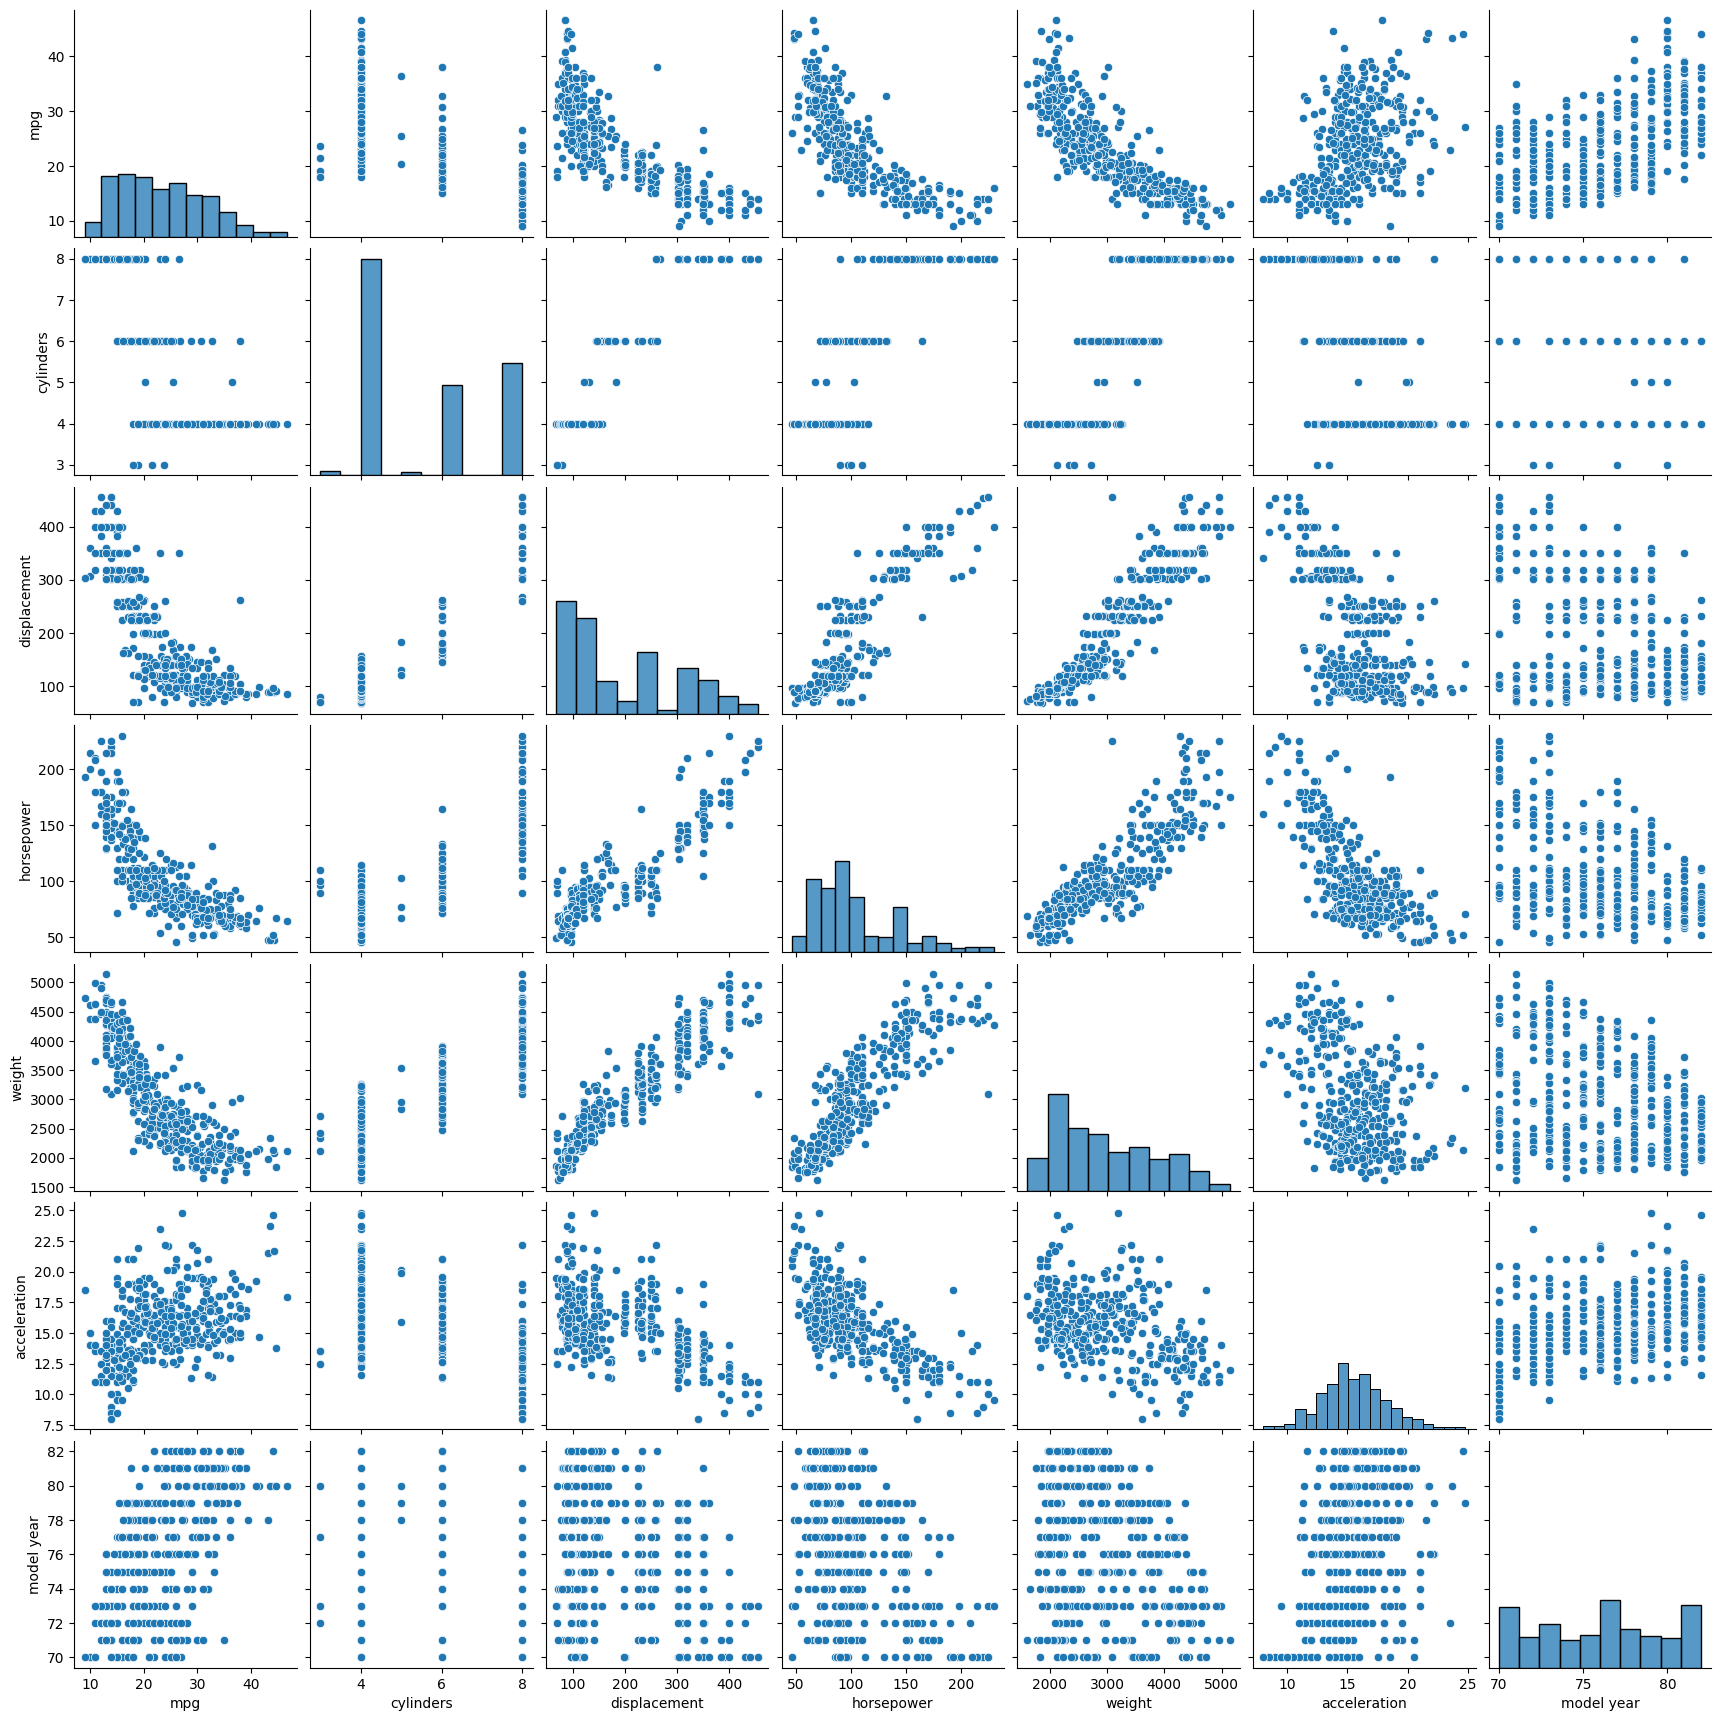

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pairplot για να δούμε σχέσεις
sns.pairplot(df[['mpg','cylinders','displacement','horsepower','weight','acceleration','model year']])
plt.show()

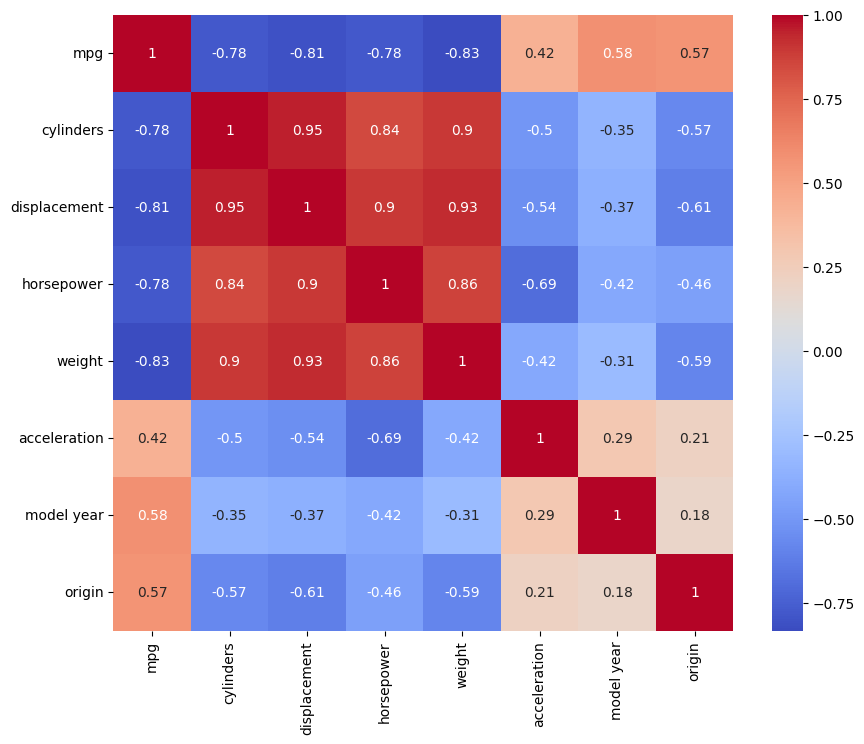

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In regression analysis, the correlation between a feature and the target variable measures the strength and direction of their linear relationship. Features with high absolute correlation (close to +1 or -1) are typically strong predictors for linear regression, while features with correlation near 0 have little linear predictive power. However, in non-linear models like Support Vector Regression (SVR) with an RBF kernel or polynomial regression, even features with low linear correlation can still be valuable, because these models can capture complex, non-linear relationships. It’s also important to watch out for multi-collinearity—features that are highly correlated with each other—since it can affect linear models, but it is less of a problem for SVR. In the Auto-MPG dataset, features like weight, cylinders, displacement, and horsepower have strong negative correlations with mpg and are highly informative, whereas features with low correlation may still contribute when using non-linear regression models

Features Distirbution

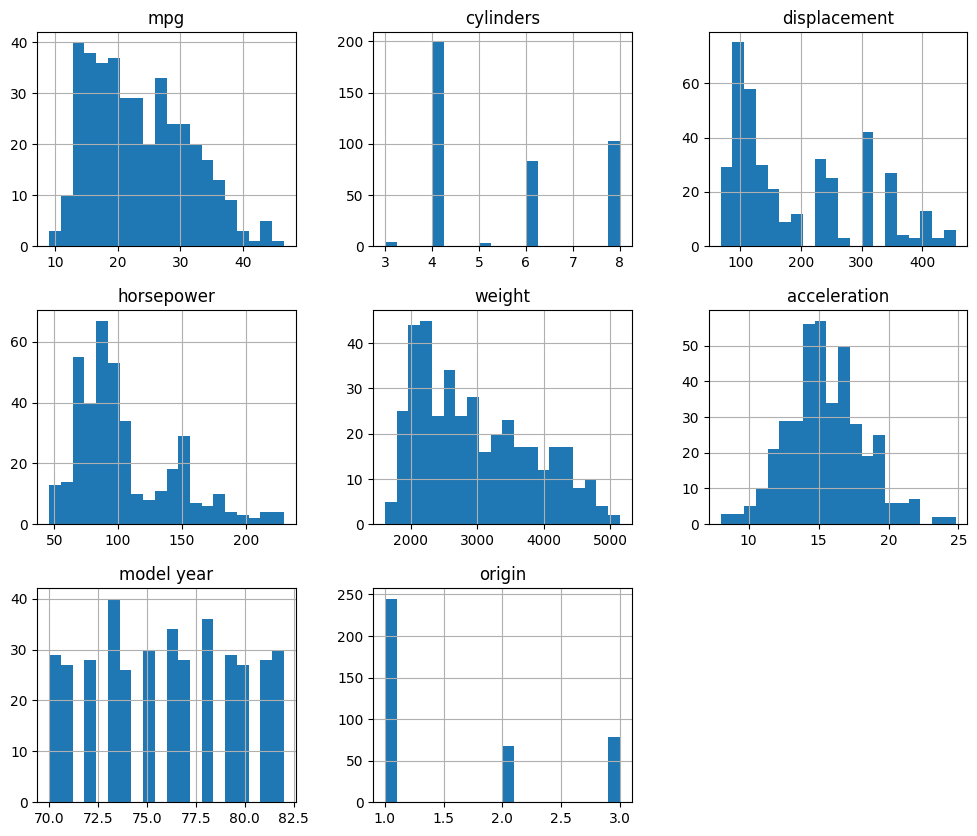

In [16]:
df.hist(bins=20, figsize=(12,10))
plt.show()

Outliers

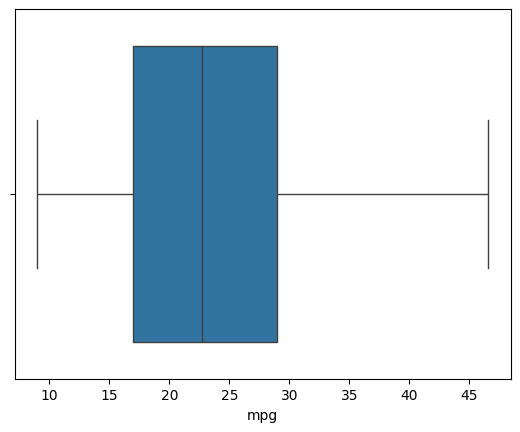

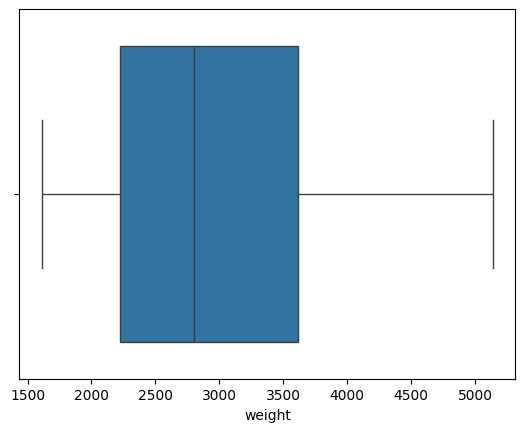

In [17]:
sns.boxplot(x=df['mpg'])
plt.show()
sns.boxplot(x=df['weight'])
plt.show()

we examine outliers in the dataset using boxplots. Boxplots display the median, interquartile range (IQR), and “whiskers” that indicate the typical range of values, while points outside the whiskers are considered potential outliers. Outliers can significantly impact regression models, especially SVR with RBF kernels and linear regression, because extreme values can disproportionately influence the model’s predictions. Identifying them allows us to decide whether to remove, transform (e.g., log or square root), or scale the features to reduce their effect. For the Auto-MPG dataset, boxplots help detect unusually heavy cars, extreme horsepower, or very high/low mpg values, ensuring that the regression models are trained on clean and properly scaled data.

Model aplication with 1 feature

In [18]:
X = df[['weight']]
y = df['mpg']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svr_model = Pipeline([
    ('scaler', StandardScaler()),   # scale features and target
    ('svr', SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))
])

svr_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR(C=100, gamma=0.1))])

In [22]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = svr_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.6985035602116683
MSE: 15.388554131539417


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


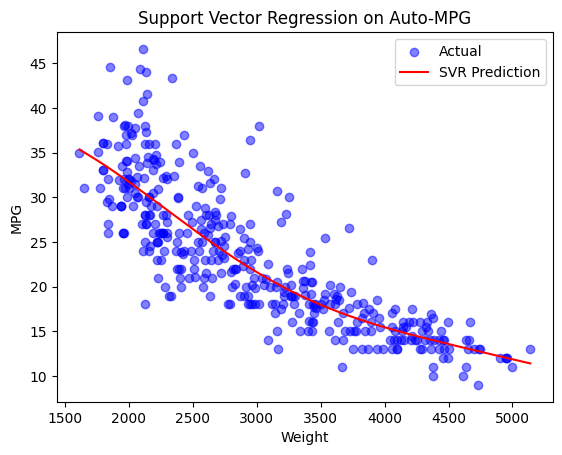

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Smooth curve for the model
X_range = np.linspace(X.min(), X.max(), 500).reshape(-1,1)

plt.scatter(X, y, color='blue', alpha=0.5, label='Actual')
plt.plot(X_range, svr_model.predict(X_range), color='red', label='SVR Prediction')
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Support Vector Regression on Auto-MPG")
plt.legend()
plt.show()

Multiple Features

In [24]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
X = df[features]
y = df['mpg']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svr_model = Pipeline([
    ('scaler', StandardScaler()),   # scale features
    ('svr', SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))
])

svr_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR(C=100, gamma=0.1))])

In [27]:
from sklearn.metrics import r2_score, mean_squared_error

y_train_pred = svr_model.predict(X_train)
y_test_pred = svr_model.predict(X_test)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train R²: 0.9147209437649789
Test R²: 0.8967679901580659
Test MSE: 5.269021991355846


no overfitting

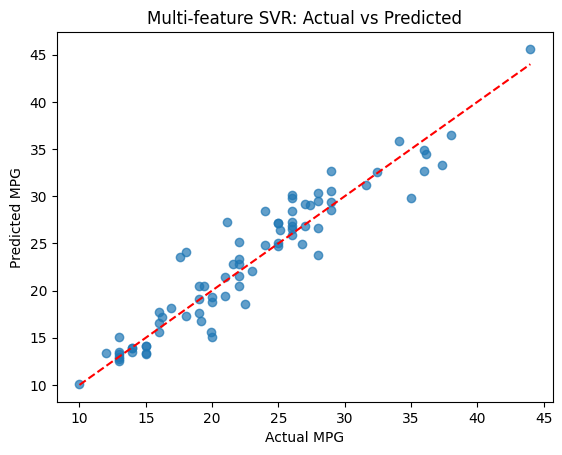

In [28]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Multi-feature SVR: Actual vs Predicted")
plt.show()